# Soldata
Med økt andel omformerbaserte ressurser (IBR-er), og flere tilfeller av systemkollaps ([South Australia Blackout](https://www.aer.gov.au/publications/reports/compliance/investigation-report-south-australias-2016-state-wide-blackout), [Odessa Disturbance](https://www.nerc.com/globalassets/programs/bpsa/alerts/2023/nerc-alert-r-2023-03-14-01-level-2---inverter-based-resource-performance-issues.pdf), [Western Interconnection Disturbances](https://www.wecc.org/sites/default/files/documents/progress_report/2025/Inverter-Based%20Resource%20Disturbances%20in%20the%20Western%20Interconnection%2011.5.2025.pdf), [Iberia Blackout](https://www.entsoe.eu/publications/blackout/28-april-2025-iberian-blackout/)) stiller nye krav til spenningsregulering og systemstabilitet. For å øke kunnskapen omkring integrering av fornybar energi i distribusjonsnettet observerer og analyseres data i forskningsanlegg. Et slikt er USN's solcelleanlegg multivariate data monitoreres, se {numref}`fig-solcelleanlegg`. Det ble satt opp våren 2024 og har samlet data siden august 2024. Data er tilgjengelig fra [USN Porsgrunn Smart Grid LAB](https://github.com/USN-Porsgrunn-Smart-Grid-LAB) på github.

In [1]:
# TEST CELL
from IPython.display import Image
from myst_nb import glue

url = "https://raw.githubusercontent.com/USN-Porsgrunn-Smart-Grid-LAB/Solardata/main/images/IMG_1187.JPG"

glue("solcelleanlegg", Image(url=url), display=False)

```{glue:figure} solcelleanlegg
:name: fig-solcelleanlegg

Nord-/Øst-vendte referansepanel (Longi) ved solcelleanlegget ved USN Porsgrunn.
```

## Innstallert effekt

Solcelleanlegets 54 paneler leverer samlet effekt på 23,76 kWp. Informasjon fra produsentens datablad er gitt i {numref}`tab-paneler`. Tester gjort av panelprodusenten under standardforhold (**Standard Test Conditions - STC**), der Effekten, $P$, er en funksjon av normert innstråling, $G$, temperatur, $T_c$ og luftmasse $AM$.

$$P_{Wp}=P(G=1000\,\mathrm{W/m^2},\,T_c=25^\circ\mathrm{C},\,AM=1.5)$$

In [25]:
# TEST CELL
from myst_nb import glue
import pandas as pd
import matplotlib.pyplot as plt

df_paneler = pd.DataFrame({
    "Paneltype": [
        "Longi LR5-66HPH-505",
        "JA Solar JAM72S20-455/MR",
        "REC 420AA Pure-R",
        "Longi Onyx LR4-60HTB-380M",
        "Sunova SS-BG545-72MDH"
    ],
    "Antall": [44, 4, 2, 2, 2],
    "Effekt per modul (Wp)": [505, 455, 420, 380, 545],
    "Sum (kWp)": [22.22, 1.82, 0.84, 0.76, 1.09]
})


glue("paneltabell", df_paneler, display=False)

plt.close(fig)



```{glue:figure} paneltabell
:name: tab-paneler

Installerte paneltyper
```

## Inverterkapasitet

Inverterkapasiteten, i {numref}`tab-inverter`, gir blant annet informasjon om hvor mye spenningsregulering som inverteren er kapabel til å levere, {numref}`fig-kap-kurve`.

In [27]:
# TEST CELL
from IPython.display import Image
import pandas as pd
from myst_nb import glue

df_invertere = pd.DataFrame({
    "Inverter": [
        "Solis S5-GC40K",
        "INVT MG4KTL",
        "APsystems DS3"
    ],
    "Omtrentlig kapasitet (kW)": [40, 4, 5]
})

# Totalrad
df_invertere.loc[len(df_invertere)] = [
    "Sum inverterkapasitet",
    49
]

glue("invertertabell", df_invertere, display=False)

```{glue:figure} invertertabell
:name: tab-inverter

Installerte invertere.
```


In [4]:
# TEST CELL
import matplotlib.pyplot as plt
from myst_nb import glue
import numpy as np


# --------------------------------------------------
# Solis S5-GC40K
# Maks tilsynelatende effekt
# --------------------------------------------------

S = 44  # kVA

# Kapasitetssirkel
P = np.linspace(-S, S, 2000)
Q = np.sqrt(S**2 - P**2)

# Eksempelpunkt for trekantene
P1 = 22
Q1 = np.sqrt(S**2 - P1**2)

P2 = 34
Q2 = -np.sqrt(S**2 - P2**2)

fig, ax = plt.subplots(figsize=(9, 9))

# --------------------------------------------------
# Hel kapasitetssirkel (svart)
# --------------------------------------------------

ax.plot(P, Q, color="black", lw=1.5)
ax.plot(P, -Q, color="black", lw=1.5)

# --------------------------------------------------
# Kapabilitetskurver (oransje og blå)
# --------------------------------------------------

mask = P >= 0

ax.plot(
    P[mask],
    Q[mask],
    color="orange",
    lw=3,
    label=r"$Q_{max}$"
)

ax.plot(
    P[mask],
    -Q[mask],
    color="dodgerblue",
    lw=3,
    label=r"$Q_{min}$"
)

# Skyggelegg tilgjengelig område
ax.fill_between(
    P[mask],
    -Q[mask],
    Q[mask],
    color="lightgray",
    alpha=0.15
)

# --------------------------------------------------
# Akser
# --------------------------------------------------

ax.axhline(0, color="black", lw=1.5)
ax.axvline(0, color="black", lw=1.5)

# --------------------------------------------------
# Rød trekant
# --------------------------------------------------

ax.fill(
    [0, P1, P1],
    [0, Q1, 0],
    color="lightcoral",
    alpha=0.4
)

ax.plot([0, P1], [0, Q1], color="red", lw=2)
ax.plot([P1, P1], [0, Q1], color="red", lw=2)
ax.plot(P1, Q1, marker="s", color="red", markersize=8)

# --------------------------------------------------
# Blå trekant
# --------------------------------------------------

ax.fill(
    [0, P2, P2],
    [0, Q2, 0],
    color="lightsteelblue",
    alpha=0.5
)

ax.plot([0, P2], [0, Q2], color="royalblue", lw=2)
ax.plot([P2, P2], [0, Q2], color="royalblue", lw=2)
ax.plot(P2, Q2, marker="s", color="steelblue", markersize=8)

# --------------------------------------------------
# Merkepunkt for Solis ved full effekt
# --------------------------------------------------

P_rated = 40
Q_rated = np.sqrt(S**2 - P_rated**2)

ax.plot(
    P_rated,
    Q_rated,
    "o",
    color="darkorange",
    markersize=10,
    label="40 kW"
)

ax.plot(
    P_rated,
    -Q_rated,
    "o",
    color="dodgerblue",
    markersize=10
)

# --------------------------------------------------
# Tekst rød trekant
# --------------------------------------------------

ax.text(
    P1 / 2 - 1,
    Q1 / 2 + 2,
    r"$kVA_1$",
    color="red",
    fontsize=16
)

ax.text(
    P1 + 1,
    Q1 / 2,
    r"$kVAR_1$",
    color="red",
    fontsize=16
)

ax.text(
    P1 / 2,
    1.2,
    r"$kW_1$",
    color="red",
    fontsize=16
)

# --------------------------------------------------
# Tekst blå trekant
# --------------------------------------------------

ax.text(
    P2 / 2 - 2,
    Q2 / 2 - 5,
    r"$kVA_2=kVA_1$",
    color="steelblue",
    fontsize=16
)

ax.text(
    P2 + 1,
    Q2 / 2,
    r"$kVAR_2$",
    color="royalblue",
    fontsize=16
)

ax.text(
    P2 / 1,
    1.5,
    r"$kW_2$",
    color="steelblue",
    fontsize=16
)

# --------------------------------------------------
# Vinkel theta
# --------------------------------------------------

ax.text(
    3,
    2,
    r"$\theta$",
    color="red",
    fontsize=18
)

# --------------------------------------------------
# Peker til kVA-rating
# --------------------------------------------------

ax.annotate(
    "kVA rating",
    xy=(38, -22),
    xytext=(52, -34),
    fontsize=14,
    arrowprops=dict(
        arrowstyle="->",
        lw=1.5
    )
)

# --------------------------------------------------
# Akseetiketter
# --------------------------------------------------

ax.text(
    50,
    1,
    "kW",
    fontsize=18,
    weight="bold"
)

ax.text(
    1,
    47,
    "kVAR",
    fontsize=18,
    weight="bold"
)

# --------------------------------------------------
# Format
# --------------------------------------------------

ax.set_title(
    "P-Q-kapasitetskurve",
    fontsize=16
)

ax.set_aspect("equal")
ax.set_xlim(-55, 60)
ax.set_ylim(-55, 55)

ax.set_xticks([])
ax.set_yticks([])

ax.legend(loc="lower left")
plt.tight_layout()
#plt.show()

glue("fig-kap-kurve", ax.figure, display=False)
plt.close(ax.figure)

```{glue:figure} fig-kap-kurve
---
name: fig-kap-kurve
width: 90%
---
Kapabilitetskurve inverter
```

In [5]:
# TEST CELL
import numpy as np
import matplotlib.pyplot as plt

P = np.linspace(0, 1.0, 500)

# Forenklede grenser
Q_upper = 0.6*np.sqrt(1 - (P-0.2)**2)
Q_lower = -0.3 - 0.2*P**2

fig, ax = plt.subplots(figsize=(8,6))

ax.plot(P, Q_upper, lw=3, color="darkorange",
        label="Overeksitasjonsgrense")

ax.plot(P, Q_lower, lw=3, color="dodgerblue",
        label="Undereksitasjonsgrense")

ax.fill_between(
    P, Q_lower, Q_upper,
    color="lightgray", alpha=0.3
)

# Statorgrense (MVA)
theta = np.linspace(-np.pi/2, np.pi/2, 400)
S = 1.0
ax.plot(
    S*np.cos(theta),
    S*np.sin(theta),
    '--k',
    label="Statorstrømgrense"
)

ax.set_xlabel("Aktiv effekt P [p.u.]")
ax.set_ylabel("Reaktiv effekt Q [p.u.]")
ax.set_title("Typisk kapabilitetsdiagram for synkrongenerator")

ax.grid(True)
ax.legend()
#plt.show()
plt.close(ax.figure)

### Paneltester

Forskjellige måter å [teste pv-panel](https://global.apsystems.com/wp-content/uploads/2020/10/APsystems-STC-vs-PTC-18SEPT2020-Rev-5.pdf) på inkluderer laboratorietest STC (Standard Test Conditions) som brukes for å angi solcellemodulens merkeeffekt (Wp). Dette representerer nær optimale forhold. PTC (PVUSA Test Conditions) representerer mer realistiske driftsforhold med 20 °C lufttemperatur og 1 m/s vind. Effekten målt under PTC er derfor vanligvis lavere enn STC-effekten. NOCT (Nominal Operating Cell Temperature) beskriver forventet celletemperatur under normale utendørs driftsforhold. Denne verdien brukes ofte i modeller for å estimere celletemperatur og temperaturtap, se {numref}`tbl-pv-conditions`.

Når solinnstråling absorberes av solcellene, omdannes bare en del av energien til elektrisitet. Resten blir til varme, noe som øker celletemperaturen. En høyere celletemperatur vil normalt redusere modulens effekt og virkningsgrad.

In [6]:
# TEST CELL
import pandas as pd
from myst_nb import glue

df_standards = pd.DataFrame({
    "Parameter": [
        "Innstråling",
        "Lufttemperatur",
        "Celletemperatur",
        "Vindhastighet",
        "Luftmasse",
        "Formål",
        "Realisme"
    ],
    "STC": [
        "1000 W/m²",
        "Typisk 0–2 °C",
        "25 °C",
        "-",
        "AM 1.5",
        "Bestemme merkeeffekt (Wp)",
        "Ideelle forhold"
    ],
    "PTC": [
        "1000 W/m²",
        "20 °C",
        "-",
        "1 m/s",
        "AM 1.5",
        "Ytelse under realistiske forhold",
        "Mer realistisk"
    ],
    "NOCT": [
        "800 W/m²",
        "20 °C",
        "45 °C ± 3 °C",
        "1 m/s",
        "AM 1.5",
        "Estimere celletemperatur",
        "Typiske driftsforhold"
    ]
})

glue("pv_conditions", df_standards, display=False)

```{glue:figure} pv_conditions
:name: tbl-pv-conditions

Sammenligning av STC, PTC og NOCT for solcellemoduler.
```

### Datablad

Databladene gir viktig informasjon som gir cellen dens elektriske karakteristikk, basert på testene. I {numref}`fig-datablad` vises et utsnitt fra databladet til referansepanelet LR5-66HPH-505M. Dette databladet dekker familien av Longi 66 HPH 495-515.

In [7]:
# TEST CELL
import matplotlib.pyplot as plt
from myst_nb import glue

img = plt.imread("../images/datablad.png")

fig, ax = plt.subplots(figsize=(12, 8))
ax.imshow(img)
ax.axis("off")
plt.close(ax.figure)
glue("datablad", fig, display=False)

```{glue:figure} datablad
:name: fig-datablad
:width: 100%

Solcellemodulens elektriske karakteristikk basert på tester.
``

### Effektivitet $\eta$

Modulens virkningsgrad er også oppgit i databladet for Longi-66HPH-505M er modul effektiviteten oppgitt til å være 21.3 % (Modul Efficiency).

Virkningsgraden til en solcelle bestemmer hvor stor andel av den innfallende solenergien som omdannes til nyttbar elektrisk energi. Virkningsgraden $\eta$ kan beregnes fra den maksimale effekten $P_m$ som følger:

$$
\eta
=
\frac{P_m}{G \cdot A}
\cdot 100\%
$$

der:

- \(\eta\) = virkningsgrad [%]
- \(P_m\) = maksimal elektrisk effekt [W]
- \(G\) = solinnstråling [W/m²]
- \(A\) = solcelleareal [m²]

Den maksimale effekten kan uttrykkes som produktet av spenning og strøm ved maksimal effektpunkt (Maximum Power Point, MPP):

$$
P_m = U_{MPP} \cdot I_{MPP}
$$

Virkningsgraden kan derfor skrives som:

$$
\eta
=
\frac{U_{MPP} \cdot I_{MPP}}
{G \cdot A}
\cdot 100\%
$$

Alternativt kan virkningsgraden uttrykkes ved hjelp av tomgangsspenningen $U_{oc}$, kortslutningsstrømmen $I_{sc}$ og fyllfaktoren $FF$:

$$
\eta
=
\frac{U_{oc} \cdot I_{sc} \cdot FF}
{G \cdot A}
\cdot 100\%
$$

hvor:

- $U_{MPP}$ = spenning ved maksimal effektpunkt [V]
- $I_{MPP}$ = strøm ved maksimal effektpunkt [A]
- $U_{oc}$ = tomgangsspenning [V]
- $I_{sc}$ = kortslutningsstrøm [A]
- $FF$ = fyllfaktor (*Fill Factor*)

{cite}`KUCZYNSKI2023`

## Enkel Modell

Den enkleste solcellemodellen skalerer effekten lineært med innstrålingen. Mer avanserte modeller korrigerer i tillegg for celletemperatur og solgeometri. Temperatur påvirker virkningsgraden, mens solgeometrien bestemmer hvor stor del av solinnstrålingen som faktisk treffer panelplanet. Dermed oppnås en mer realistisk beregning av solkraftproduksjonen gjennom året.

$$P_{Wp}=P(G=1000\,\mathrm{W/m^2},\,T_c=25^\circ\mathrm{C},\,AM=1.5)$$

Den enkleste solcellemodellen antar at den produserte effekten er proporsjonal med innstrålingen. Dette gir en lineær sammenheng mellom innstråling og effekt:

$$
P = P_{Wp}\frac{G}{G_{STC}}
$$

der $P_{Wp}$ er modulens nominelle effekt ved standard testbetingelser (STC):

$$
P_{Wp}
=
P(G=1000\,\mathrm{W/m^2},
T_c=25^\circ\mathrm{C},
AM=1.5)
$$

### Utvidet modell

Mer avanserte modeller korrigerer i tillegg for celletemperatur og solgeometri. Temperatur påvirker panelvirkningsgraden, mens solgeometrien bestemmer hvor stor del av solinnstrålingen som faktisk treffer panelplanet. Dermed oppnås en mer realistisk beregning av solkraftproduksjonen gjennom året.

Den enkle modellen kan utvides ved å ta hensyn til celletemperaturen:

$$
P =
P_{Wp}
\frac{G}{G_{STC}}
\left[1+\gamma(T_c-25)\right]
$$

der $\gamma$ er temperaturkoeffisienten til solcellemodulen, typisk negativ for silisiumbaserte solceller.

Modellen beskriver hvordan effekten påvirkes både av innstrålingen og av celletemperaturen. Økt innstråling gir høyere effekt, mens høyere celletemperatur vanligvis reduserer virkningsgraden og dermed effekten.

Modellen er fortsatt lineær med hensyn til innstrålingen $G$, men inkluderer nå en temperaturkorreksjon som gjør den mer realistisk enn den enkle STC-modellen.

### Geografisk informasjonssystem for solenergi

Det finnes geografisk informasjonssystem for solenergi som PVVGIS (Photovoltaic Geographical Information System). PVGIS benytter solgeometri, satellittbaserte strålingsdata og meteorologiske datasett til å estimere lokal solinnstråling. Metoden kan sammenlignes med romlig interpolasjon mellom observasjonspunkter, men inkluderer i tillegg fysiske modeller for solens bane og atmosfærisk påvirkning. PVGIS benyttes til å generere tidsserier for innstråling og temperatur basert på anleggets geografiske lokasjon. Disse dataene brukes videre til å estimere effekt- og energiproduksjonen fra solcelleanlegget.

In [8]:
# TEST CELL
import matplotlib.pyplot as plt
from myst_nb import glue

img = plt.imread("../images/pvgis_start_en.png")

fig, ax = plt.subplots(figsize=(12, 8))
ax.imshow(img)
ax.axis("off")
plt.close(ax.figure)
glue("freq_response", fig, display=False)

```{glue:figure} freq_response
:name: fig-pvgis
:width: 100%

PVGIS startside.
``

### API-kall fra PVGIS

PVGIS har også et eget API-kall.

Strat med: 

Importere bibliotek

In [9]:
import requests
import pandas as pd


Informasjon om ytelse og panelhelning hentes fra datablader, se {numref}`fig-van-der-valk`.

In [10]:
# TEST CELL
import matplotlib.pyplot as plt
from myst_nb import glue

img = plt.imread("../images/vandervalk.png")

fig, ax = plt.subplots(figsize=(12, 8))
ax.imshow(img)
ax.axis("off")
plt.close(ax.figure)
glue("vandervalk", fig, display=False)

```{glue:figure} vandervalk
:name: fig-van-der-valk
:width: 100%

Datablad montering.
``

PVGIS sitt seriescalc-API, versjon 5.3, henter tidsserier for solinnstråling og meteorologiske data for anleggets lokasjon. Anlegget ble modellert med en installert effekt på 26,73 kWp (peakpower), et antatt systemtap på 14 % (loss), panelhelning på 15$^{\circ}$ (angle), se numref og sørvendt orientering (aspect=0). Selv om anlegget består av flere orienteringer, benytter vi her en forenklet representasjon for å generere en samlet produksjonsprofil. Gjør en request på data som returneres som `.json`. Lager datatabell som `df`.

In [11]:
lat = 59.137337
lon = 9.671440

url = (
    f"https://re.jrc.ec.europa.eu/api/v5_3/seriescalc"
    f"?lat={lat}"
    f"&lon={lon}"
    f"&peakpower=26.73"
    f"&loss=14"
    f"&angle=12"
    f"&aspect=0"
    f"&outputformat=json"
)

data = requests.get(url).json()

df = pd.DataFrame(data["outputs"]["hourly"])

print(df.columns)
print(df.head())

Index(['time', 'G(i)', 'H_sun', 'T2m', 'WS10m', 'Int'], dtype='object')
            time  G(i)  H_sun   T2m  WS10m  Int
0  20050101:0011   0.0    0.0 -2.56   2.41  0.0
1  20050101:0111   0.0    0.0 -2.49   2.55  0.0
2  20050101:0211   0.0    0.0 -2.10   2.48  0.0
3  20050101:0311   0.0    0.0 -1.56   2.21  0.0
4  20050101:0411   0.0    0.0 -1.04   2.34  0.0


In [12]:
df["time"] = (
pd.to_datetime(df["time"], format="%Y%m%d:%H%M")
.dt.round("h")
)

df = df.set_index("time")
print(df.head())

                     G(i)  H_sun   T2m  WS10m  Int
time                                              
2005-01-01 00:00:00   0.0    0.0 -2.56   2.41  0.0
2005-01-01 01:00:00   0.0    0.0 -2.49   2.55  0.0
2005-01-01 02:00:00   0.0    0.0 -2.10   2.48  0.0
2005-01-01 03:00:00   0.0    0.0 -1.56   2.21  0.0
2005-01-01 04:00:00   0.0    0.0 -1.04   2.34  0.0


In [13]:
## import pandas as pd

P_wp = 26.73         # kWp
gamma = -0.004       # 1/°C
NOCT = 45            # °C


df["Tc"] = (
    df["T2m"]
    + ((NOCT - 20) / 800) * df["G(i)"]
)

df["p_kw"] = (
    P_wp
    * (df["G(i)"] / 1000)
    * (1 + gamma * (df["Tc"] - 25))
)

df["p_kw"] = df["p_kw"].clip(lower=0)

pv_profile = df[["p_kw"]]

print(pv_profile)

                     p_kw
time                     
2005-01-01 00:00:00   0.0
2005-01-01 01:00:00   0.0
2005-01-01 02:00:00   0.0
2005-01-01 03:00:00   0.0
2005-01-01 04:00:00   0.0
...                   ...
2023-12-31 19:00:00   0.0
2023-12-31 20:00:00   0.0
2023-12-31 21:00:00   0.0
2023-12-31 22:00:00   0.0
2023-12-31 23:00:00   0.0

[166536 rows x 1 columns]


In [14]:
df['G(i)'].loc['2005-07-15']

time
2005-07-15 00:00:00      0.00
2005-07-15 01:00:00      0.00
2005-07-15 02:00:00      0.00
2005-07-15 03:00:00      0.00
2005-07-15 04:00:00     48.37
2005-07-15 05:00:00     16.85
2005-07-15 06:00:00     54.51
2005-07-15 07:00:00     55.51
2005-07-15 08:00:00    139.76
2005-07-15 09:00:00    128.85
2005-07-15 10:00:00    148.68
2005-07-15 11:00:00    150.66
2005-07-15 12:00:00    222.02
2005-07-15 13:00:00    164.54
2005-07-15 14:00:00    159.58
2005-07-15 15:00:00    211.45
2005-07-15 16:00:00    153.66
2005-07-15 17:00:00    200.76
2005-07-15 18:00:00     78.88
2005-07-15 19:00:00     45.23
2005-07-15 20:00:00      7.87
2005-07-15 21:00:00      0.00
2005-07-15 22:00:00      0.00
2005-07-15 23:00:00      0.00
Name: G(i), dtype: float64

In [30]:
from myst_nb import glue
import matplotlib.pyplot as plt

# serie = timeserien din
serie = df["G(i)"].loc['2005-07-15'] # tilpass til ditt datasett

fig, ax = plt.subplots(figsize=(8, 4))

serie.plot(ax=ax)

ax.set_title("Global innstråling 15. juli 2005")
ax.set_xlabel("Tid")
ax.set_ylabel(r"Innstråling [W/m$^2$]")
ax.grid(True)

plt.tight_layout()

glue("fig-innstraling", fig, display=False)
plt.close(fig)

```{glue:figure} fig-innstraling
:name: fig-innstraling

Global innstråling, $G(i)$, for 15. juli 2005.
```

[pandapower_docs](https://pandapower.readthedocs.io/en/latest/index.html#)
[pandapower_tutorial](https://pandapower.readthedocs.io/en/v1.4.2/getting_started/tutorials.html)

# Pandapower




### Nettmodell


Data:

- Spenning: 400 V trefase
- Kabel 1: 100 m
- Kabel 2: 100 m
- r = 0.642 Ω/km
- x = 0.083 Ω/km
- PV-produksjon = 0 kW

---

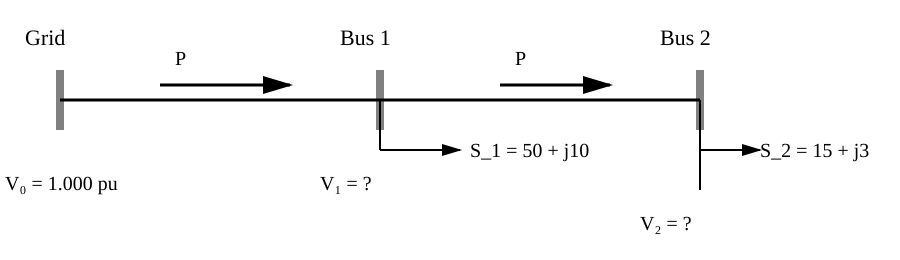

In [33]:
# TEST CELL
from myst_nb import glue
from IPython.display import SVG

svg = """
<svg width="900" height="260"
     xmlns="http://www.w3.org/2000/svg">

  <defs>
    <marker id="arrow"
            markerWidth="10"
            markerHeight="10"
            refX="9"
            refY="3"
            orient="auto">
      <path d="M0,0 L10,3 L0,6 z"
            fill="black"/>
    </marker>
  </defs>

  <!-- Busser -->

  <line x1="60" y1="70"
        x2="60" y2="130"
        stroke="gray"
        stroke-width="8"/>

  <line x1="380" y1="70"
        x2="380" y2="130"
        stroke="gray"
        stroke-width="8"/>

  <line x1="700" y1="70"
        x2="700" y2="130"
        stroke="gray"
        stroke-width="8"/>

  <!-- Linjer -->

  <line x1="60" y1="100"
        x2="380" y2="100"
        stroke="black"
        stroke-width="3"/>

  <line x1="380" y1="100"
        x2="700" y2="100"
        stroke="black"
        stroke-width="3"/>

  <!-- Effektflyt -->

  <line x1="160" y1="85"
        x2="290" y2="85"
        stroke="black"
        stroke-width="3"
        marker-end="url(#arrow)" />

  <text x="175" y="65"
        font-size="20">
        P
  </text>

  <line x1="500" y1="85"
        x2="610" y2="85"
        stroke="black"
        stroke-width="3"
        marker-end="url(#arrow)" />

  <text x="515" y="65"
        font-size="20">
        P
  </text>

  <!-- Grid -->

  <text x="25" y="45"
        font-size="22">
        Grid
  </text>

  <!-- Bus-navn -->

  <text x="340" y="45"
        font-size="22">
        Bus 1
  </text>

  <text x="660" y="45"
        font-size="22">
        Bus 2
  </text>

  <!-- Last 1 -->

  <line x1="380" y1="100"
        x2="380" y2="150"
        stroke="black"
        stroke-width="2"/>

  <line x1="380" y1="150"
        x2="460" y2="150"
        stroke="black"
        stroke-width="2"
        marker-end="url(#arrow)"/>

  <text x="470" y="157"
        font-size="20">
        S_1 = 50 + j10
  </text>

  <!-- Last 2 -->

  <line x1="700" y1="100"
        x2="700" y2="190"
        stroke="black"
        stroke-width="2"/>

  <line x1="700" y1="150"
        x2="760" y2="150"
        stroke="black"
        stroke-width="2"
        marker-end="url(#arrow)"/>

  <text x="760" y="157"
        font-size="20">
       S_2 = 15 + j3
  </text>

<!-- PV -->

  <line x1="700" y1="100"
        x2="700" y2="190"
        stroke="black"
        stroke-width="2"/>



  <!-- Spenninger -->

  <text x="5" y="190"
        font-size="20">
        V₀ = 1.000 pu
  </text>

  <text x="320" y="190"
        font-size="20">
        V₁ = ?
  </text>

  <text x="640" y="230"
        font-size="20">
        V₂ = ?
  </text>

</svg>
"""

glue("revers_flyt", SVG(svg), display=True)

### Effektdata

Baseeffekt:

$$
S_B = 100\ \text{kVA}
$$

## Businformasjon

| Buss | Type   | P (pu) | Q (pu) | Spenning |
|------|--------|--------|--------|--------|
| Bus 0 | Slack | Ukjent | Ukjent | $V_0, 1\angle0^{\circ}$ |
| Bus 1 | PQ    | -0.50  | -0.10 | $V_1$ ukjent |
| Bus 2 | PQ    | -0.15  | -0.03 | $V_2$ ukjent |


$$ V_i^{(k+1)} = \frac{1}{Y_{ii}} \left( \frac{P_i-jQ_i} {\left(V_i^{(k)}\right)^*} - \sum_{j\ne i} Y_{ij}V_j \right)$$

## Per-unit impedans og admittans

Baseimpedansen er

$$
Z_B
=
\frac{V_B^2}{S_B}
=
\frac{400^2}{100000}
=
1.6\ \Omega
$$

Linjeimpedansen i per unit lengden tatt i betraktning
$$
z_{pu}
=
\frac{0.0642+j0.0083}{1.6}
$$

$$
z_{pu}
=
0.040125+j0.0051875
$$

Linjeadmittansen i per unit er

$$
y_{pu}
=
\frac{1}{z}
$$

$$
y_{pu}
=
\frac{1}{0.040125+j0.0051875}
$$

$$
y_{pu}
=
24.51-j3.17
$$

$$
Y_{bus}
=
\begin{bmatrix}
24.51-j3.17 & -24.51+j3.17 & 0\\
-24.51+j3.17 & 49.02-j6.34 & -24.51+j3.17\\
0 & -24.51+j3.17 & 24.51-j3.17
\end{bmatrix}
$$

In [42]:
# TEST CELL

import numpy as np

Y = np.array([
    [ 24.51-1j*3.17, -24.51+1j*3.17,   0.00+0j      ],
    [-24.51+1j*3.17,  49.02-1j*6.34, -24.51+1j*3.17],
    [  0.00+0j,      -24.51+1j*3.17,  24.51-1j*3.17]
], dtype=complex)


# Slack-buss
V0 = 1 + 0j

# PQ-laster (100 kVA base)
P1, Q1 = -0.50, -0.10
P2, Q2 = -0.15, -0.03

# --------------------------------------------------
# Flat start
# --------------------------------------------------

V1 = 1 + 0j
V2 = 1 + 0j

# --------------------------------------------------
# Gauss-Seidel
# --------------------------------------------------

tol = 1e-8
max_iter = 100

for k in range(max_iter):

    V1_old = V1
    V2_old = V2

    # Buss 1
    V1 = (
        (P1 - 1j * Q1) / np.conj(V1)
        - Y[1,0] * V0
        - Y[1,2] * V2
    ) / Y[1,1]

    # Buss 2
    V2 = (
        (P2 - 1j * Q2) / np.conj(V2)
        - Y[2,1] * V1
    ) / Y[2,2]

    error = max(
        abs(V1 - V1_old),
        abs(V2 - V2_old)
    )

    print(
        f"Iterasjon {k+1:2d}: "
        f"|V1|={abs(V1):.6f} pu, "
        f"|V2|={abs(V2):.6f} pu"
    )

    if error < tol:
        break

# --------------------------------------------------
# Resultater
# --------------------------------------------------

print("\nKonvergert løsning")
print("------------------")

print(
    f"Bus 0: |V|={abs(V0):.6f} pu, "
    f"vinkel={np.degrees(np.angle(V0)):.4f}°"
)

print(
    f"Bus 1: |V|={abs(V1):.6f} pu, "
    f"vinkel={np.degrees(np.angle(V1)):.4f}°"
)

print(
    f"Bus 2: |V|={abs(V2):.6f} pu, "
    f"vinkel={np.degrees(np.angle(V2)):.4f}°"
)

Iterasjon  1: |V1|=0.989709 pu, |V2|=0.983534 pu
Iterasjon  2: |V1|=0.981368 pu, |V2|=0.975090 pu
Iterasjon  3: |V1|=0.977058 pu, |V2|=0.970725 pu
Iterasjon  4: |V1|=0.974829 pu, |V2|=0.968467 pu
Iterasjon  5: |V1|=0.973676 pu, |V2|=0.967299 pu
Iterasjon  6: |V1|=0.973079 pu, |V2|=0.966695 pu
Iterasjon  7: |V1|=0.972770 pu, |V2|=0.966383 pu
Iterasjon  8: |V1|=0.972611 pu, |V2|=0.966221 pu
Iterasjon  9: |V1|=0.972528 pu, |V2|=0.966137 pu
Iterasjon 10: |V1|=0.972485 pu, |V2|=0.966094 pu
Iterasjon 11: |V1|=0.972463 pu, |V2|=0.966071 pu
Iterasjon 12: |V1|=0.972452 pu, |V2|=0.966060 pu
Iterasjon 13: |V1|=0.972446 pu, |V2|=0.966054 pu
Iterasjon 14: |V1|=0.972443 pu, |V2|=0.966051 pu
Iterasjon 15: |V1|=0.972441 pu, |V2|=0.966049 pu
Iterasjon 16: |V1|=0.972440 pu, |V2|=0.966048 pu
Iterasjon 17: |V1|=0.972440 pu, |V2|=0.966048 pu
Iterasjon 18: |V1|=0.972440 pu, |V2|=0.966048 pu
Iterasjon 19: |V1|=0.972440 pu, |V2|=0.966047 pu
Iterasjon 20: |V1|=0.972440 pu, |V2|=0.966047 pu
Iterasjon 21: |V1|=0

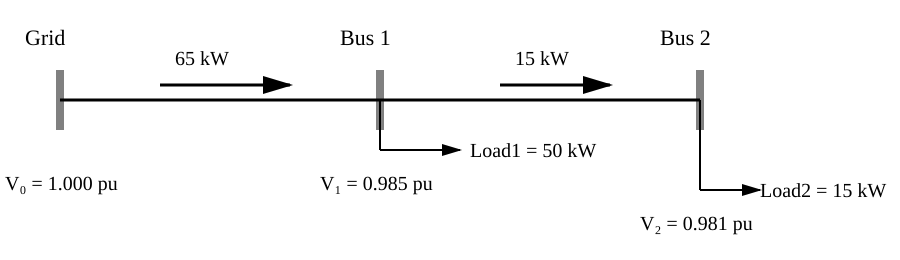

In [16]:
# TEST CELL
from IPython.display import SVG, display

svg = """
<svg width="900" height="260"
     xmlns="http://www.w3.org/2000/svg">

  <defs>
    <marker id="arrow"
            markerWidth="10"
            markerHeight="10"
            refX="9"
            refY="3"
            orient="auto">
      <path d="M0,0 L10,3 L0,6 z"
            fill="black"/>
    </marker>
  </defs>

  <!-- Busser -->

  <line x1="60" y1="70"
        x2="60" y2="130"
        stroke="gray"
        stroke-width="8"/>

  <line x1="380" y1="70"
        x2="380" y2="130"
        stroke="gray"
        stroke-width="8"/>

  <line x1="700" y1="70"
        x2="700" y2="130"
        stroke="gray"
        stroke-width="8"/>

  <!-- Linjer -->

  <line x1="60" y1="100"
        x2="380" y2="100"
        stroke="black"
        stroke-width="3"/>

  <line x1="380" y1="100"
        x2="700" y2="100"
        stroke="black"
        stroke-width="3"/>

  <!-- Effektflyt -->

  <line x1="160" y1="85"
        x2="290" y2="85"
        stroke="black"
        stroke-width="3"
        marker-end="url(#arrow)" />

  <text x="175" y="65"
        font-size="20">
        65 kW
  </text>

  <line x1="500" y1="85"
        x2="610" y2="85"
        stroke="black"
        stroke-width="3"
        marker-end="url(#arrow)" />

  <text x="515" y="65"
        font-size="20">
        15 kW
  </text>

  <!-- Grid -->

  <text x="25" y="45"
        font-size="22">
        Grid
  </text>

  <!-- Bus-navn -->

  <text x="340" y="45"
        font-size="22">
        Bus 1
  </text>

  <text x="660" y="45"
        font-size="22">
        Bus 2
  </text>

  <!-- Last 1 -->

  <line x1="380" y1="100"
        x2="380" y2="150"
        stroke="black"
        stroke-width="2"/>

  <line x1="380" y1="150"
        x2="460" y2="150"
        stroke="black"
        stroke-width="2"
        marker-end="url(#arrow)"/>

  <text x="470" y="157"
        font-size="20">
        Load1 = 50 kW
  </text>

  <!-- Last 2 -->

  <line x1="700" y1="100"
        x2="700" y2="190"
        stroke="black"
        stroke-width="2"/>

  <line x1="700" y1="190"
        x2="760" y2="190"
        stroke="black"
        stroke-width="2"
        marker-end="url(#arrow)"/>

  <text x="760" y="197"
        font-size="20">
        Load2 = 15 kW
  </text>

  <!-- Spenninger -->

  <text x="5" y="190"
        font-size="20">
        V₀ = 1.000 pu
  </text>

  <text x="320" y="190"
        font-size="20">
        V₁ = 0.985 pu
  </text>

  <text x="640" y="230"
        font-size="20">
        V₂ = 0.981 pu
  </text>

</svg>
"""

display(SVG(svg))

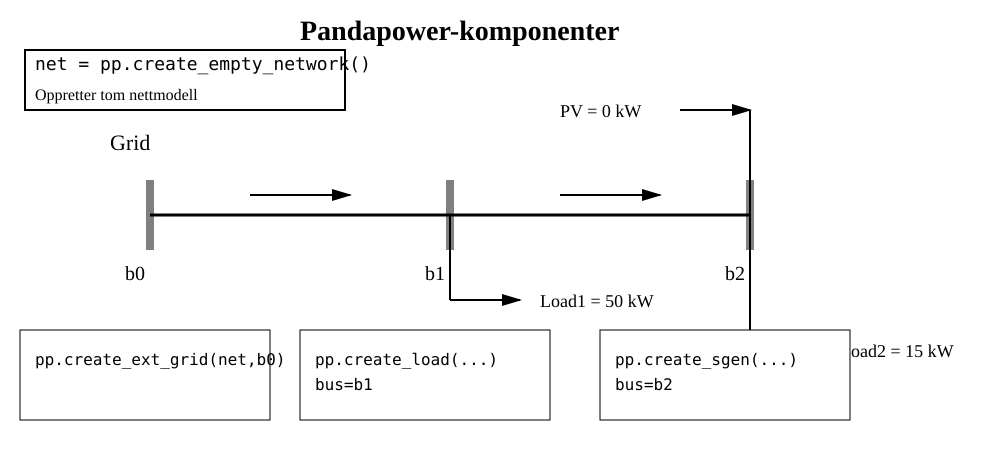

In [18]:
# TEST CELL
from IPython.display import SVG, display

svg = """
<svg width="1000" height="450"
     xmlns="http://www.w3.org/2000/svg">

  <defs>
    <marker id="arrow"
      markerWidth="10"
      markerHeight="10"
      refX="9"
      refY="3"
      orient="auto">
      <path d="M0,0 L10,3 L0,6 z" fill="black"/>
    </marker>
  </defs>

  <!-- Tittel -->
  <text x="300" y="40"
        font-size="28"
        font-weight="bold">
    Pandapower-komponenter
  </text>

<!-- create_empty_network -->

<rect x="25"
      y="50"
      width="320"
      height="60"
      fill="white"
      stroke="black"
      stroke-width="2"/>

<text x="35"
      y="70"
      font-family="monospace"
      font-size="18">
net = pp.create_empty_network()
</text>

<text x="35"
      y="100"
      font-size="16">
Oppretter tom nettmodell
</text>

  <!-- Nettdiagram -->

  <!-- Busser -->
  <line x1="150" y1="180" x2="150" y2="250"
        stroke="gray" stroke-width="8"/>

  <line x1="450" y1="180" x2="450" y2="250"
        stroke="gray" stroke-width="8"/>

  <line x1="750" y1="180" x2="750" y2="250"
        stroke="gray" stroke-width="8"/>

  <!-- Linjer -->
  <line x1="150" y1="215" x2="450" y2="215"
        stroke="black" stroke-width="3"/>

  <line x1="450" y1="215" x2="750" y2="215"
        stroke="black" stroke-width="3"/>

  <!-- Effektpiler -->
  <line x1="250" y1="195"
        x2="350" y2="195"
        stroke="black"
        stroke-width="2"
        marker-end="url(#arrow)"/>

  <line x1="560" y1="195"
        x2="660" y2="195"
        stroke="black"
        stroke-width="2"
        marker-end="url(#arrow)"/>

  <!-- Grid -->
  <text x="110" y="150"
        font-size="22">
    Grid
  </text>

  <!-- Bus labels -->
  <text x="125" y="280"
        font-size="20">
    b0
  </text>

  <text x="425" y="280"
        font-size="20">
    b1
  </text>

  <text x="725" y="280"
        font-size="20">
    b2
  </text>

  <!-- Last 1 -->
  <line x1="450" y1="215"
        x2="450" y2="300"
        stroke="black"
        stroke-width="2"/>

  <line x1="450" y1="300"
        x2="520" y2="300"
        stroke="black"
        stroke-width="2"
        marker-end="url(#arrow)"/>

  <text x="540" y="307"
        font-size="18">
    Load1 = 50 kW
  </text>

  <!-- Last 2 -->
  <line x1="750" y1="215"
        x2="750" y2="350"
        stroke="black"
        stroke-width="2"/>

  <line x1="750" y1="350"
        x2="820" y2="350"
        stroke="black"
        stroke-width="2"
        marker-end="url(#arrow)"/>

  <text x="840" y="357"
        font-size="18">
    Load2 = 15 kW
  </text>

  <!-- PV -->
  <line x1="750" y1="215"
        x2="750" y2="110"
        stroke="black"
        stroke-width="2"/>

  <line x1="680" y1="110"
        x2="750" y2="110"
        stroke="black"
        stroke-width="2"
        marker-end="url(#arrow)"/>

  <text x="560" y="117"
        font-size="18">
    PV = 0 kW
  </text>

  <!-- Kodebokser -->

  <rect x="20" y="330"
        width="250"
        height="90"
        fill="white"
        stroke="black"/>

  <text x="35" y="365"
        font-family="monospace"
        font-size="16">
pp.create_ext_grid(net,b0)
  </text>

  <rect x="300" y="330"
        width="250"
        height="90"
        fill="white"
        stroke="black"/>

  <text x="315" y="365"
        font-family="monospace"
        font-size="16">
pp.create_load(...)
  </text>

  <text x="315" y="390"
        font-family="monospace"
        font-size="16">
bus=b1
  </text>

  <rect x="600" y="330"
        width="250"
        height="90"
        fill="white"
        stroke="black"/>

  <text x="615" y="365"
        font-family="monospace"
        font-size="16">
pp.create_sgen(...)
  </text>

  <text x="615" y="390"
        font-family="monospace"
        font-size="16">
bus=b2
  </text>

</svg>
"""
display(SVG(svg))

# Hva gjør Pandapower?


```python
pp.runpp(net)
```

og sammenligner med:

```python
net.res_bus
```

```python
net.res_line
```

```python
net.res_ext_grid
```



In [31]:
import pandapower as pp
import pandapower.plotting as plot
import matplotlib.pyplot as plt

# --------------------------------------------------
# Opprett nett
# --------------------------------------------------

net = pp.create_empty_network()

# --------------------------------------------------
# Busser
# --------------------------------------------------

b0 = pp.create_bus(
    net,
    vn_kv=0.4,
    name="Trafo",
    geodata=(0, 0)
)

b1 = pp.create_bus(
    net,
    vn_kv=0.4,
    name="Load",
    geodata=(1, 0)
)

b2 = pp.create_bus(
    net,
    vn_kv=0.4,
    name="PV",
    geodata=(2, 0)
)



# --------------------------------------------------
# Nettstasjon
# --------------------------------------------------

pp.create_ext_grid(net, b0)

# --------------------------------------------------
# Linjer
# --------------------------------------------------

line1 = pp.create_line_from_parameters(
    net,
    b0, b1,
    length_km=0.1,
    r_ohm_per_km=0.642,
    x_ohm_per_km=0.083,
    c_nf_per_km=0,
    max_i_ka=0.2
)

line2 = pp.create_line_from_parameters(
    net,
    b1, b2,
    length_km=0.1,
    r_ohm_per_km=0.642,
    x_ohm_per_km=0.083,
    c_nf_per_km=0,
    max_i_ka=0.2
)

# --------------------------------------------------
# Last
# --------------------------------------------------


# Last ved Bus1
pp.create_load(
    net,
    bus=b1,
    p_mw=0.050,   # 50 kW
    q_mvar=0.010,
    name="Load1"
)

# Last ved Bus2
pp.create_load(
    net,
    bus=b2,
    p_mw=0.015,   # 15 kW
    q_mvar=0.003,
    name="Load2"
)

# --------------------------------------------------
# PV-anlegg 44 kWp
# --------------------------------------------------

#pv = pp.create_sgen(
#    net,
#    bus=b2,
#    p_mw=0.021, #
#    q_mvar =0.11,
#    name="PV"
#)

# --------------------------------------------------
# Lastflyt
# --------------------------------------------------

pp.runpp(net, numba=False)

# --------------------------------------------------
# Resultater
# --------------------------------------------------

print("\nBus-spenninger")
print(net.res_bus.vm_pu)
print(net.res_bus[["vm_pu", "va_degree"]])
print("\nEffekt fra nettet")
print(net.res_ext_grid.p_mw)

print("\nEffektflyt i linjer")
print(net.res_line[["p_from_mw"]])

#print('nett',net.load)

# --------------------------------------------------
# Plott nett
# --------------------------------------------------

#plt.figure(figsize=(8,3))

#plot.simple_plot(
#    net,
#    bus_size=1,
#    line_width=2,
#    plot_loads=True,
#    plot_sgens=True
#)


#plt.show()


Bus-spenninger
0    1.000000
1    0.972442
2    0.966051
Name: vm_pu, dtype: float64
      vm_pu  va_degree
0  1.000000   0.000000
1  0.972442   0.108670
2  0.966051   0.134629

Effekt fra nettet
0    0.066971
Name: p_mw, dtype: float64

Effektflyt i linjer
   p_from_mw
0   0.066971
1   0.015101



# Neste steg: Solkraft

PV-produksjon legges til:

```python
net.sgen.at[pv, 'p_mw'] = 0.04
```

Da kan vi undersøke:

- Hvordan strømmer endres
- Hvordan spenninger endres
- Redusert nettimport
- Revers effektflyt




In [43]:
# TEST CELL
import pandapower as pp
import pandapower.plotting as plot
import matplotlib.pyplot as plt

# --------------------------------------------------
# Opprett nett
# --------------------------------------------------

net = pp.create_empty_network()

# --------------------------------------------------
# Busser
# --------------------------------------------------

b0 = pp.create_bus(
    net,
    vn_kv=0.4,
    name="Trafo",
    geodata=(0, 0)
)

b1 = pp.create_bus(
    net,
    vn_kv=0.4,
    name="Load",
    geodata=(1, 0)
)

b2 = pp.create_bus(
    net,
    vn_kv=0.4,
    name="PV",
    geodata=(2, 0)
)



# --------------------------------------------------
# Nettstasjon
# --------------------------------------------------

pp.create_ext_grid(net, b0)

# --------------------------------------------------
# Linjer
# --------------------------------------------------

line1 = pp.create_line_from_parameters(
    net,
    b0, b1,
    length_km=0.1,
    r_ohm_per_km=0.642,
    x_ohm_per_km=0.083,
    c_nf_per_km=0,
    max_i_ka=0.2
)

line2 = pp.create_line_from_parameters(
    net,
    b1, b2,
    length_km=0.1,
    r_ohm_per_km=0.642,
    x_ohm_per_km=0.083,
    c_nf_per_km=0,
    max_i_ka=0.2
)

# --------------------------------------------------
# Last
# --------------------------------------------------


# Last ved Bus1
pp.create_load(
    net,
    bus=b1,
    p_mw=0.050,   # 50 kW
    q_mvar=0.010,
    name="Load1"
)

# Last ved Bus2
pp.create_load(
    net,
    bus=b2,
    p_mw=0.015,   # 15 kW
    q_mvar=0.003,
    name="Load2"
)

# --------------------------------------------------
# PV-anlegg 44 kWp
# --------------------------------------------------

pv = pp.create_sgen(
    net,
    bus=b2,
    p_mw=0.021, #
    q_mvar =0.11,
    name="PV"
)

# --------------------------------------------------
# Lastflyt
# --------------------------------------------------

pp.runpp(net, numba=False)

# --------------------------------------------------
# Resultater
# --------------------------------------------------

print("\nBus-spenninger")
print(net.res_bus.vm_pu)
print(net.res_bus[["vm_pu", "va_degree"]])
print("\nEffekt fra nettet")
print(net.res_ext_grid.p_mw)

print("\nEffektflyt i linjer")
print(net.res_line[["p_from_mw"]])

#print('nett',net.load)

# --------------------------------------------------
# Plott nett
# --------------------------------------------------

#plt.figure(figsize=(8,3))

#plot.simple_plot(
#    net,
#    bus_size=1,
#    line_width=2,
#    plot_loads=True,
#    plot_sgens=True
#)


#plt.show()


Bus-spenninger
0    1.000000
1    0.984357
2    0.991444
Name: vm_pu, dtype: float64
      vm_pu  va_degree
0  1.000000   0.000000
1  0.984357  -2.399019
2  0.991444  -4.902123

Effekt fra nettet
0    0.053518
Name: p_mw, dtype: float64

Effektflyt i linjer
   p_from_mw
0   0.053518
1  -0.001312


                         G     PV_kW    V_bus1    V_bus2  P_nett_kW
tid                                                                
2005-07-15 00:00:00   0.00  0.000000  0.972442  0.966051  66.970741
2005-07-15 01:00:00   0.00  0.000000  0.972442  0.966051  66.970741
2005-07-15 02:00:00   0.00  0.000000  0.972442  0.966051  66.970741
2005-07-15 03:00:00   0.00  0.000000  0.972442  0.966051  66.970741
2005-07-15 04:00:00  48.37  1.141532  0.972933  0.967021  65.749740


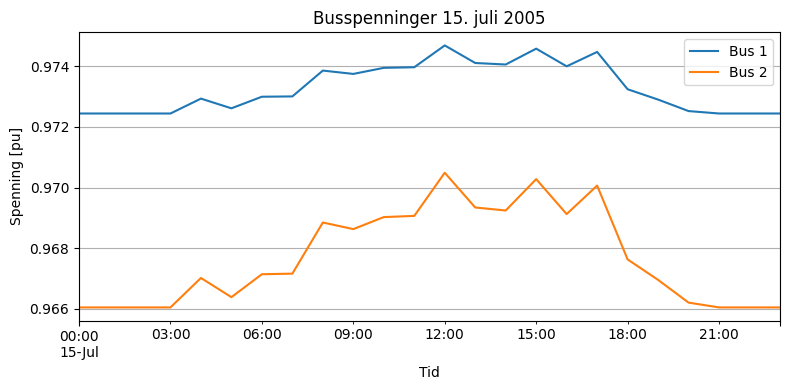

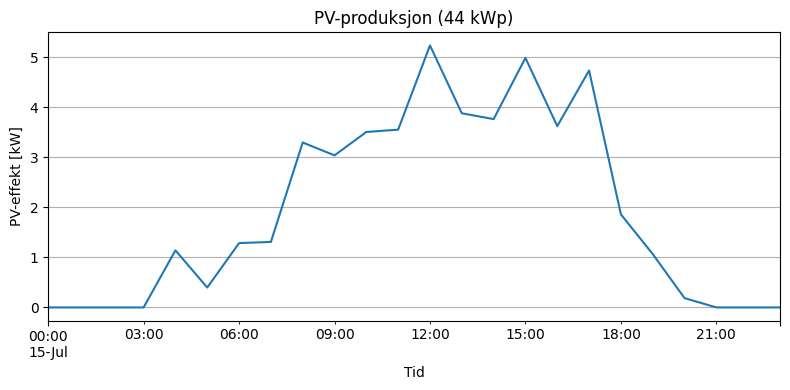

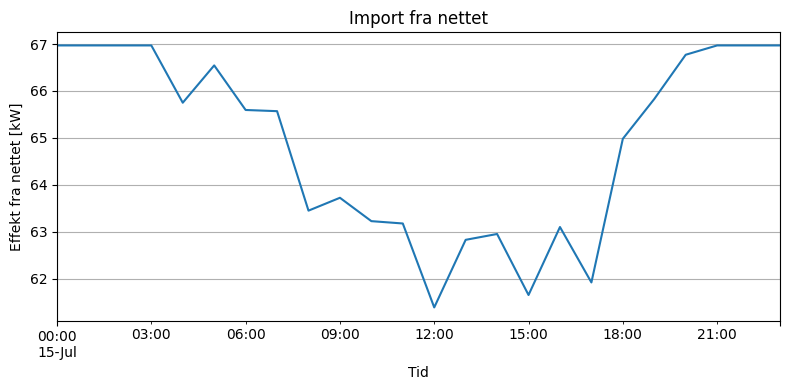

In [41]:
# TEST CELL
import warnings

warnings.filterwarnings("ignore")
import pandas as pd
import pandapower as pp
import matplotlib.pyplot as plt
import numba


# --------------------------------------------------
# Hent innstråling for én dag
# --------------------------------------------------

serie = df["G(i)"].loc["2005-07-15"]

# --------------------------------------------------
# Opprett nett
# --------------------------------------------------

net = pp.create_empty_network()

b0 = pp.create_bus(
    net,
    vn_kv=0.4,
    name="Trafo",
    geodata=(0, 0)
)

b1 = pp.create_bus(
    net,
    vn_kv=0.4,
    name="Load",
    geodata=(1, 0)
)

b2 = pp.create_bus(
    net,
    vn_kv=0.4,
    name="PV",
    geodata=(2, 0)
)

# --------------------------------------------------
# Slack-buss
# --------------------------------------------------

pp.create_ext_grid(net, b0)

# --------------------------------------------------
# Linjer
# --------------------------------------------------

pp.create_line_from_parameters(
    net,
    b0,
    b1,
    length_km=0.1,
    r_ohm_per_km=0.642,
    x_ohm_per_km=0.083,
    c_nf_per_km=0,
    max_i_ka=0.2
)

pp.create_line_from_parameters(
    net,
    b1,
    b2,
    length_km=0.1,
    r_ohm_per_km=0.642,
    x_ohm_per_km=0.083,
    c_nf_per_km=0,
    max_i_ka=0.2
)

# --------------------------------------------------
# Last
# --------------------------------------------------

pp.create_load(
    net,
    bus=b1,
    p_mw=0.050,
    q_mvar=0.010,
    name="Load1"
)

pp.create_load(
    net,
    bus=b2,
    p_mw=0.015,
    q_mvar=0.003,
    name="Load2"
)

# --------------------------------------------------
# PV-anlegg (44 kWp)
# --------------------------------------------------

pv_idx = pp.create_sgen(
    net,
    bus=b2,
    p_mw=0.0,
    q_mvar=0.0,
    name="PV"
)

# --------------------------------------------------
# Tidsserie-simulering
# --------------------------------------------------

resultater = []

for tidspunkt, G in serie.items():

    # 44 kWp ved 1000 W/m²

    p_pv_kw = 23.6 * G / 1000.0

    net.sgen.at[pv_idx, "p_mw"] = p_pv_kw / 1000

    pp.runpp(net, numba=False)

    resultater.append(
        {
            "tid": tidspunkt,
            "G": G,
            "PV_kW": p_pv_kw,
            "V_bus1": net.res_bus.vm_pu.at[b1],
            "V_bus2": net.res_bus.vm_pu.at[b2],
            "P_nett_kW": net.res_ext_grid.p_mw.at[0] * 1000,
        }
    )

# --------------------------------------------------
# Resultater i DataFrame
# --------------------------------------------------

res = pd.DataFrame(resultater)
res = res.set_index("tid")

print(res.head())

# --------------------------------------------------
# Plot spenninger
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(8,4))

res["V_bus1"].plot(ax=ax, label="Bus 1")
res["V_bus2"].plot(ax=ax, label="Bus 2")

ax.set_ylabel("Spenning [pu]")
ax.set_xlabel("Tid")
ax.set_title("Busspenninger 15. juli 2005")
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()

# --------------------------------------------------
# Plot PV-produksjon
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(8,4))

res["PV_kW"].plot(ax=ax)

ax.set_ylabel("PV-effekt [kW]")
ax.set_xlabel("Tid")
ax.set_title("PV-produksjon (44 kWp)")
ax.grid(True)

plt.tight_layout()
plt.show()

# --------------------------------------------------
# Plot effekt fra nettet
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(8,4))

res["P_nett_kW"].plot(ax=ax)

ax.set_ylabel("Effekt fra nettet [kW]")
ax.set_xlabel("Tid")
ax.set_title("Import fra nettet")
ax.grid(True)

plt.tight_layout()
plt.show()